# Total Emissions Explorer

Downloads all decomposed files from S3 and generates charts of `total_emissions` by `primary_id` and `time_period`.

**Flow:**
1. Configuration and S3 connection
2. List files in `MODEL_OUTPUT_PREFIX`
3. List and download all decomposed files from `S3_DECOMPOSED_PREFIX`
4. Merge into a single DataFrame with `primary_id`, `time_period`, `total_emissions`
5. Visualization
6. Download `cb_outputs` and visualize `technical_cost`

---
## 0. Imports

In [99]:
import os
import yaml
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from io import StringIO
from concurrent.futures import ThreadPoolExecutor, as_completed
try:
    from tqdm import tqdm
except Exception:
    tqdm = lambda x, **k: x

print("Imports OK")

Imports OK


---
## 1. Configuration

In [100]:
DIR_ID  = "130"
RUN_ID  = "sisepuede_run_2026-03-10t13;27;53.264959"

SCRIPT_DIR  = os.path.abspath(".")
CONFIG_PATH = os.path.join(SCRIPT_DIR, "config", "aws_credentials_config.yaml")

with open(CONFIG_PATH) as f:
    aws_config = yaml.safe_load(f)

PROFILE_NAME = aws_config["profile_name"]
BUCKET_NAME  = aws_config["bucket_name"]

RUN_DB_PREFIX        = f"run_database/{RUN_ID}/"
MODEL_OUTPUT_PREFIX  = f"{RUN_DB_PREFIX}model_output/region=uganda/model_output_{DIR_ID}/"
S3_DECOMPOSED_PREFIX = f"{RUN_DB_PREFIX}decomposed_outputs/"
S3_CB_PREFIX         = f"{RUN_DB_PREFIX}cb_outputs/"

print(f"Profile        : {PROFILE_NAME}")
print(f"Bucket         : {BUCKET_NAME}")
print(f"MODEL_OUTPUT   : {MODEL_OUTPUT_PREFIX}")
print(f"DECOMPOSED     : {S3_DECOMPOSED_PREFIX}")
print(f"CB_OUTPUTS     : {S3_CB_PREFIX}")

Profile        : fabian
Bucket         : sisepuede-data
MODEL_OUTPUT   : run_database/sisepuede_run_2026-03-10t13;27;53.264959/model_output/region=uganda/model_output_130/
DECOMPOSED     : run_database/sisepuede_run_2026-03-10t13;27;53.264959/decomposed_outputs/
CB_OUTPUTS     : run_database/sisepuede_run_2026-03-10t13;27;53.264959/cb_outputs/


---
## 2. S3 Connection

In [101]:
session = boto3.Session(profile_name=PROFILE_NAME)
s3      = session.resource("s3")
bucket  = s3.Bucket(BUCKET_NAME)

try:
    s3.meta.client.head_bucket(Bucket=BUCKET_NAME)
    print("S3 Connection: OK")
except Exception as e:
    print(f"S3 ERROR: {e}")

S3 Connection: OK


---
## 3. List files in MODEL_OUTPUT_PREFIX

In [102]:
model_objects = list(bucket.objects.filter(Prefix=MODEL_OUTPUT_PREFIX))

print(f"Files found in MODEL_OUTPUT_PREFIX: {len(model_objects)}")
for obj in model_objects:
    size_mb = obj.size / 1024 / 1024
    print(f"  {obj.key.replace(MODEL_OUTPUT_PREFIX, '')}  ({size_mb:.1f} MB)")

Files found in MODEL_OUTPUT_PREFIX: 1
  data.csv  (40.5 MB)


---
## 4. List decomposed files in S3_DECOMPOSED_PREFIX

In [103]:
decomposed_objects = list(bucket.objects.filter(Prefix=S3_DECOMPOSED_PREFIX))

# Filter only emission CSVs
emission_keys = [
    obj.key for obj in decomposed_objects
    if obj.key.endswith(".csv") and "decomposed_emissions" in obj.key
]

print(f"Total files in decomposed_outputs : {len(decomposed_objects)}")
print(f"Emission CSV files                : {len(emission_keys)}")
if emission_keys:
    print(f"Example: {emission_keys[0]}")

Total files in decomposed_outputs : 619
Emission CSV files                : 619
Example: run_database/sisepuede_run_2026-03-10t13;27;53.264959/decomposed_outputs/region=uganda/decomposed_emissions_1/data.csv


---
## 5. Download all decomposed files (parallel)

Only `primary_id`, `time_period`, `total_emissions` columns are kept to minimize memory usage.

In [104]:
COLS_NEEDED = ["primary_id", "time_period", "total_emissions"]
MAX_WORKERS = 20

def download_emission_file(key):
    """Download a CSV from S3 and return only the required columns."""
    try:
        obj     = s3.Object(BUCKET_NAME, key)
        content = obj.get()["Body"].read().decode("utf-8")
        df      = pd.read_csv(StringIO(content), usecols=COLS_NEEDED)
        return df
    except Exception as e:
        print(f"ERROR downloading {key}: {e}")
        return None


frames = []
errors = []

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(download_emission_file, key): key for key in emission_keys}
    for future in tqdm(as_completed(futures), total=len(futures), desc="Downloading"):
        result = future.result()
        if result is not None:
            frames.append(result)
        else:
            errors.append(futures[future])

print(f"\nDownloaded : {len(frames)} files")
print(f"Errors     : {len(errors)} files")


Downloaded : 619 files
Errors     : 0 files


---
## 6. Merge all DataFrames

In [105]:
df = pd.concat(frames, ignore_index=True)
df = df.sort_values(["primary_id", "time_period"]).reset_index(drop=True)

n_ids = df["primary_id"].nunique()
print(f"Total shape        : {df.shape}")
print(f"Unique primary_ids : {n_ids}")
print(f"time_period range  : {df['time_period'].min()} – {df['time_period'].max()}")
print(f"total_emissions    : min={df['total_emissions'].min():.2f}, max={df['total_emissions'].max():.2f}")
df.head()

Total shape        : (1034800, 3)
Unique primary_ids : 19900
time_period range  : 4 – 55
total_emissions    : min=32.01, max=1073626103196.13


,primary_id,time_period,total_emissions
0,700070,4,111.777536
1,700070,5,113.675323
2,700070,6,113.472624
3,700070,7,116.025587
4,700070,8,118.680967


In [106]:
df = df[df["primary_id"] != 770077]

---
## 7. Visualization of total_emissions

### 7a. Fan chart — distribution by time_period

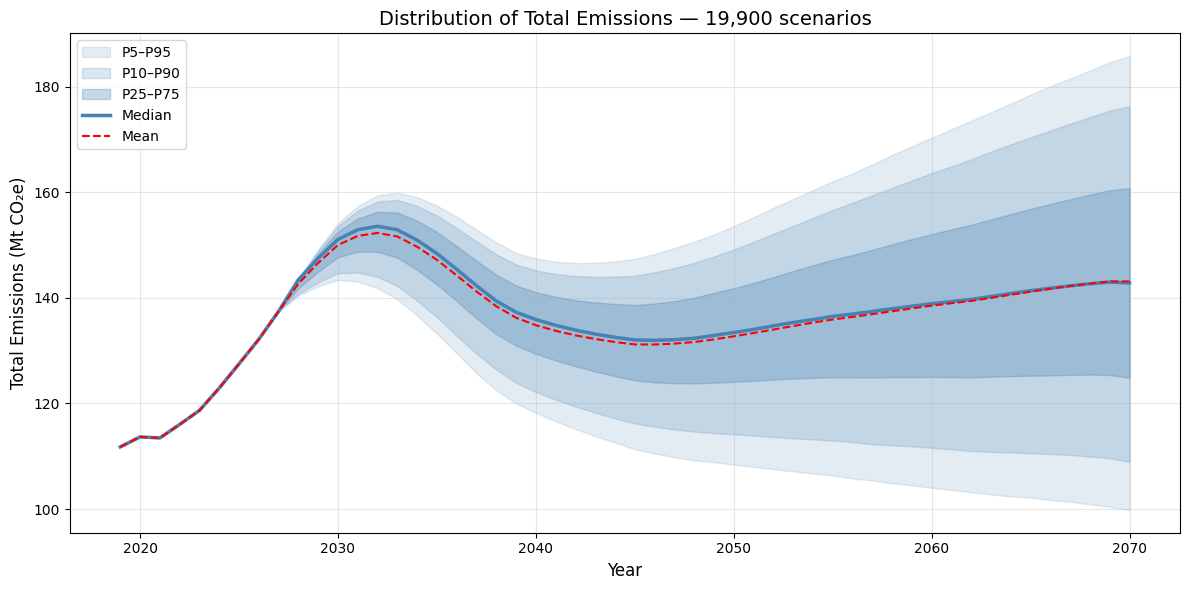

In [107]:
# Calculate percentiles by time_period
stats = df.groupby("time_period")["total_emissions"].describe(
    percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
).reset_index()

years = stats["time_period"] + 2015  # time_period 0 = 2015

fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(years, stats["5%"],  stats["95%"],  alpha=0.15, color="steelblue", label="P5–P95")
ax.fill_between(years, stats["10%"], stats["90%"],  alpha=0.20, color="steelblue", label="P10–P90")
ax.fill_between(years, stats["25%"], stats["75%"],  alpha=0.30, color="steelblue", label="P25–P75")
ax.plot(years, stats["50%"],  color="steelblue", linewidth=2.5, label="Median")
ax.plot(years, stats["mean"], color="red",       linewidth=1.5, linestyle="--", label="Mean")

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Total Emissions (Mt CO₂e)", fontsize=12)
ax.set_title(f"Distribution of Total Emissions — {n_ids:,} scenarios", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig("total_emissions_fan_chart.png", dpi=150)
plt.show()


### 7b. Box plot by year

/var/folders/fj/jc6_dph55kg8wg_040b7gk980000gn/T/ipykernel_51758/713304232.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(grouped, labels=years_list, patch_artist=True,


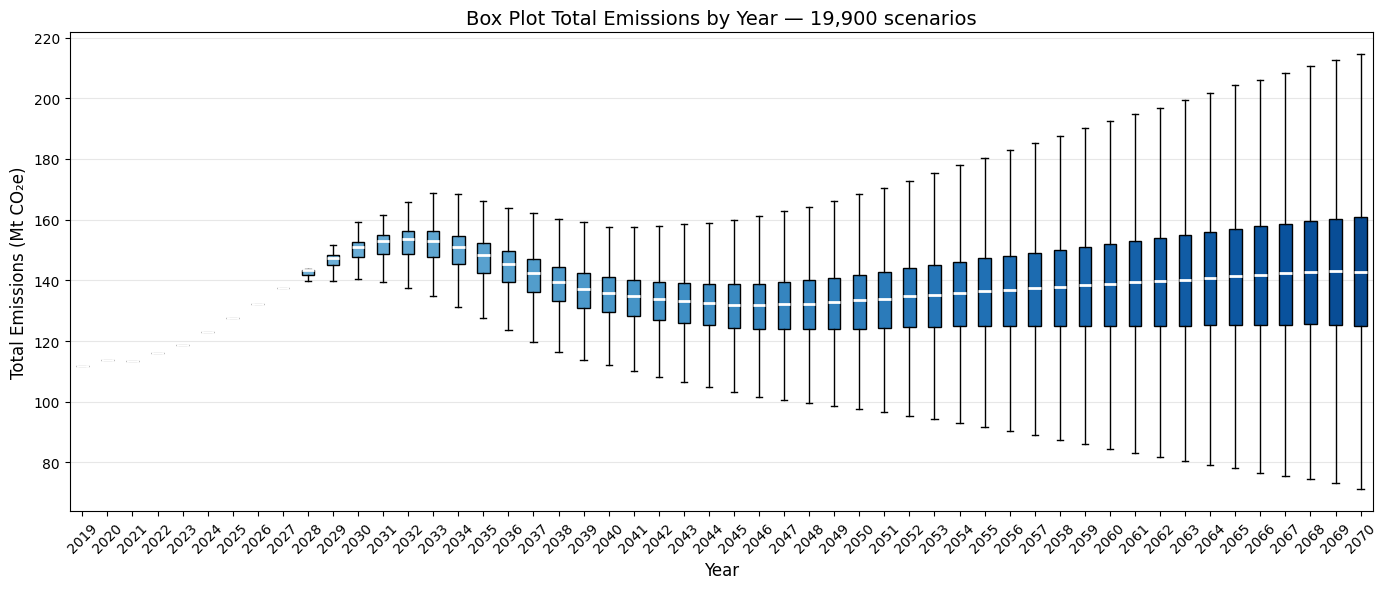

Done: total_emissions_boxplot.png


In [108]:
df_plot = df.copy()
df_plot["year"] = df_plot["time_period"] + 2015

grouped = [group["total_emissions"].values for _, group in df_plot.groupby("year")]
years_list = sorted(df_plot["year"].unique())

fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot(grouped, labels=years_list, patch_artist=True,
                showfliers=False, medianprops=dict(color="white", linewidth=2))

colors = cm.Blues(np.linspace(0.4, 0.9, len(grouped)))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Total Emissions (Mt CO₂e)", fontsize=12)
ax.set_title(f"Box Plot Total Emissions by Year — {n_ids:,} scenarios", fontsize=14)
ax.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
#plt.savefig("total_emissions_boxplot.png", dpi=150)
plt.show()
print("Done: total_emissions_boxplot.png")

### 7c. Histogram of total_emissions for a reference year (2022)

### 7c. Spaghetti — one line per primary_id

/var/folders/fj/jc6_dph55kg8wg_040b7gk980000gn/T/ipykernel_51758/4055054581.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10)


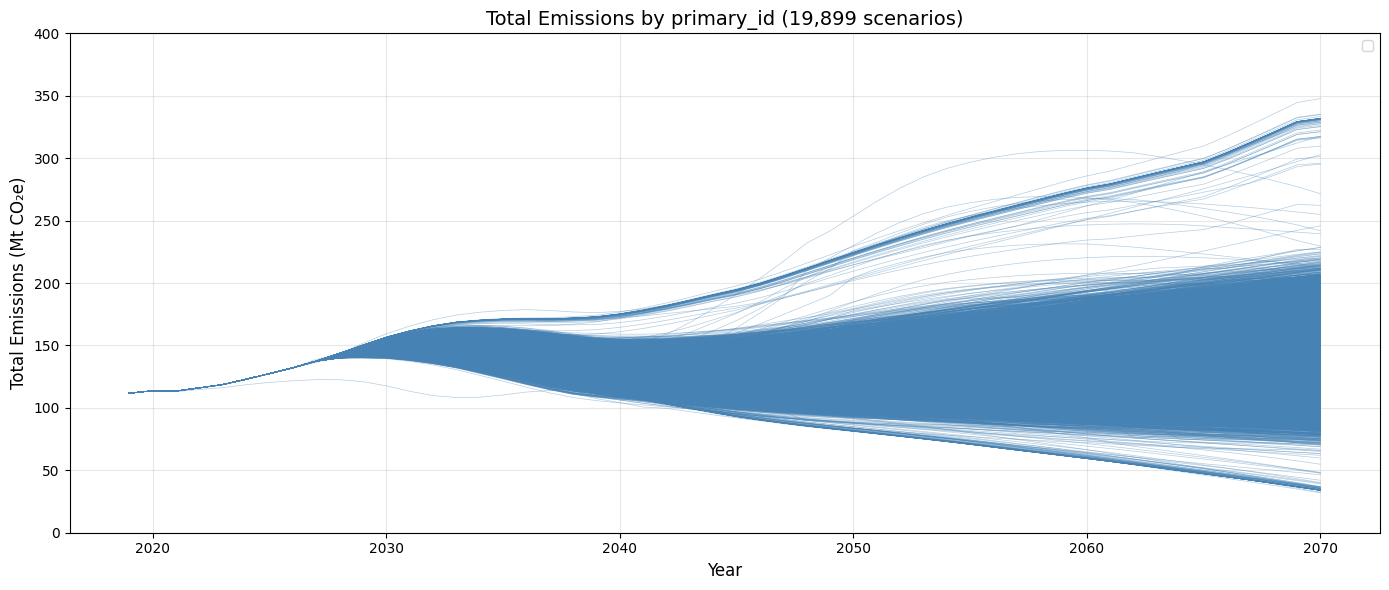

In [109]:
pivot = df.pivot_table(index="time_period", columns="primary_id", values="total_emissions")
years_arr = pivot.index.values + 2015

fig, ax = plt.subplots(figsize=(14, 6))

# All lines except baseline
non_baseline_cols = [c for c in pivot.columns if c != 0]
ax.plot(years_arr, pivot[non_baseline_cols].values, color="steelblue", linewidth=0.5, alpha=0.4)

# Baseline in red
if 0 in pivot.columns:
    baseline_vals = pivot[0].values
    ax.plot(years_arr, baseline_vals, color="red", linewidth=2, label="Baseline (primary_id=0)", zorder=5)

    # Annotation at end of line
    ax.annotate(
        "Baseline",
        xy=(years_arr[-1], baseline_vals[-1]),
        xytext=(8, 0),
        textcoords="offset points",
        color="red",
        fontsize=10,
        fontweight="bold",
        va="center",
    )

ax.set_ylim(0, 400)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Total Emissions (Mt CO₂e)", fontsize=12)
ax.set_title(f"Total Emissions by primary_id ({len(pivot.columns):,} scenarios)", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig("total_emissions_spaghetti.png", dpi=150)
plt.show()

---
## 9. Download cb_outputs from S3

Same parallel download process, keeping only `primary_id`, `time_period`, and `technical_cost`.

In [110]:
cb_objects = list(bucket.objects.filter(Prefix=S3_CB_PREFIX))

# Filter only CSV files
cb_keys = [
    obj.key for obj in cb_objects
    if obj.key.endswith(".csv")
]

print(f"Total files in cb_outputs : {len(cb_objects)}")
print(f"CSV files found           : {len(cb_keys)}")
if cb_keys:
    print(f"Example: {cb_keys[0]}")

Total files in cb_outputs : 619
CSV files found           : 619
Example: run_database/sisepuede_run_2026-03-10t13;27;53.264959/cb_outputs/region=uganda/cb_1/data.csv


In [111]:


def download_cb_file(key):
    """Download a cb_outputs CSV from S3 and return only required columns."""
    try:
        obj     = s3.Object(BUCKET_NAME, key)
        content = obj.get()["Body"].read().decode("utf-8")
        df      = pd.read_csv(StringIO(content))
        return df
    except Exception as e:
        print(f"ERROR downloading {key}: {e}")
        return None


cb_frames = []
cb_errors = []

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures_cb = {executor.submit(download_cb_file, key): key for key in cb_keys}
    for future in tqdm(as_completed(futures_cb), total=len(futures_cb), desc="Downloading cb_outputs"):
        result = future.result()
        if result is not None:
            cb_frames.append(result)
        else:
            cb_errors.append(futures_cb[future])

print(f"\nDownloaded : {len(cb_frames)} files")
print(f"Errors     : {len(cb_errors)} files")


Downloaded : 619 files
Errors     : 0 files


In [112]:
df_cb = pd.concat(cb_frames, ignore_index=True)
df_cb = df_cb.sort_values(["primary_id", "time_period"]).reset_index(drop=True)

n_cb_ids = df_cb["primary_id"].nunique()
print(f"Total shape        : {df_cb.shape}")
print(f"Unique primary_ids : {n_cb_ids}")
print(f"time_period range  : {df_cb['time_period'].min()} – {df_cb['time_period'].max()}")
print(f"technical_cost     : min={df_cb['technical_cost'].min():.2f}, max={df_cb['technical_cost'].max():.2f}")
df_cb.head()

Total shape        : (1034800, 19)
Unique primary_ids : 19900
time_period range  : 4 – 55
technical_cost     : min=-629249627548.79, max=1206817286427.48


,primary_id,time_period,air_pollution,congestion,consumer_savings,crop_value,ecosystem_services,env_pollution,fuel_cost,human_health,ippu_value,land_pollution,lvst_value,road_safety,sector_specific,system_cost,technical_cost,technical_savings,water_pollution
0,700070,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,700070,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,700070,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,700070,7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,700070,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [113]:
# Rank primary_ids by mean technical_cost (ascending)
df_cb_rank = (
    df_cb.groupby("primary_id")["technical_cost"]
    .sum()
    .reset_index()
    .rename(columns={"technical_cost": "technical_cost"})
    .sort_values("technical_cost", ascending=True)
    .reset_index(drop=True)
)

df_cb_rank.head(20)

,primary_id,technical_cost
0,6528001,-9.355494e+09
1,6529860,-1.996220e+09
2,8469730,-4.811414e+08
3,6525372,-3.112165e+08
4,6527284,-2.131098e+08
5,8468627,-5.576708e+07
6,6521959,-4.273745e+07
7,6523729,-3.829170e+07
8,8466462,-2.712887e+07
9,6527178,-2.239609e+07


---
## 10. Visualization of technical_cost

### 10a. Fan chart — distribution by time_period

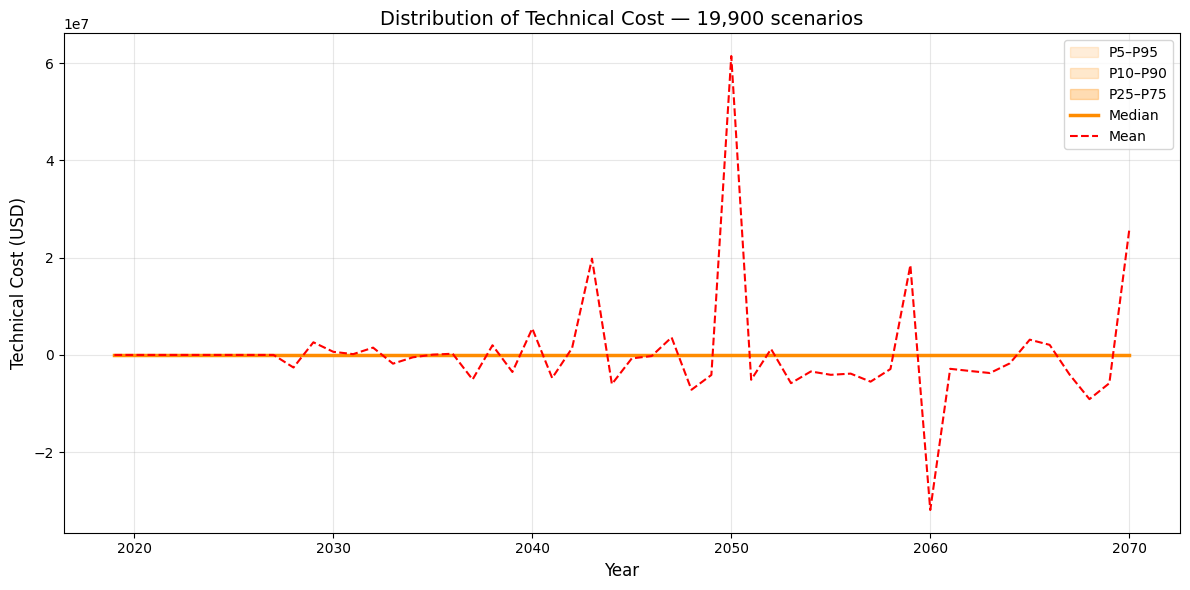

In [117]:
# Calculate percentiles by time_period
cb_stats = df_cb.groupby("time_period")["technical_cost"].describe(
    percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
).reset_index()

cb_years = cb_stats["time_period"] + 2015  # time_period 0 = 2015

fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(cb_years, cb_stats["5%"],  cb_stats["95%"],  alpha=0.15, color="darkorange", label="P5–P95")
ax.fill_between(cb_years, cb_stats["10%"], cb_stats["90%"],  alpha=0.20, color="darkorange", label="P10–P90")
ax.fill_between(cb_years, cb_stats["25%"], cb_stats["75%"],  alpha=0.30, color="darkorange", label="P25–P75")
ax.plot(cb_years, cb_stats["50%"],  color="darkorange", linewidth=2.5, label="Median")
ax.plot(cb_years, cb_stats["mean"], color="red",        linewidth=1.5, linestyle="--", label="Mean")

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Technical Cost (USD)", fontsize=12)
ax.set_title(f"Distribution of Technical Cost — {n_cb_ids:,} scenarios", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 10b. Box plot by year

/var/folders/fj/jc6_dph55kg8wg_040b7gk980000gn/T/ipykernel_51758/877505899.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(cb_grouped, labels=cb_years_list, patch_artist=True,


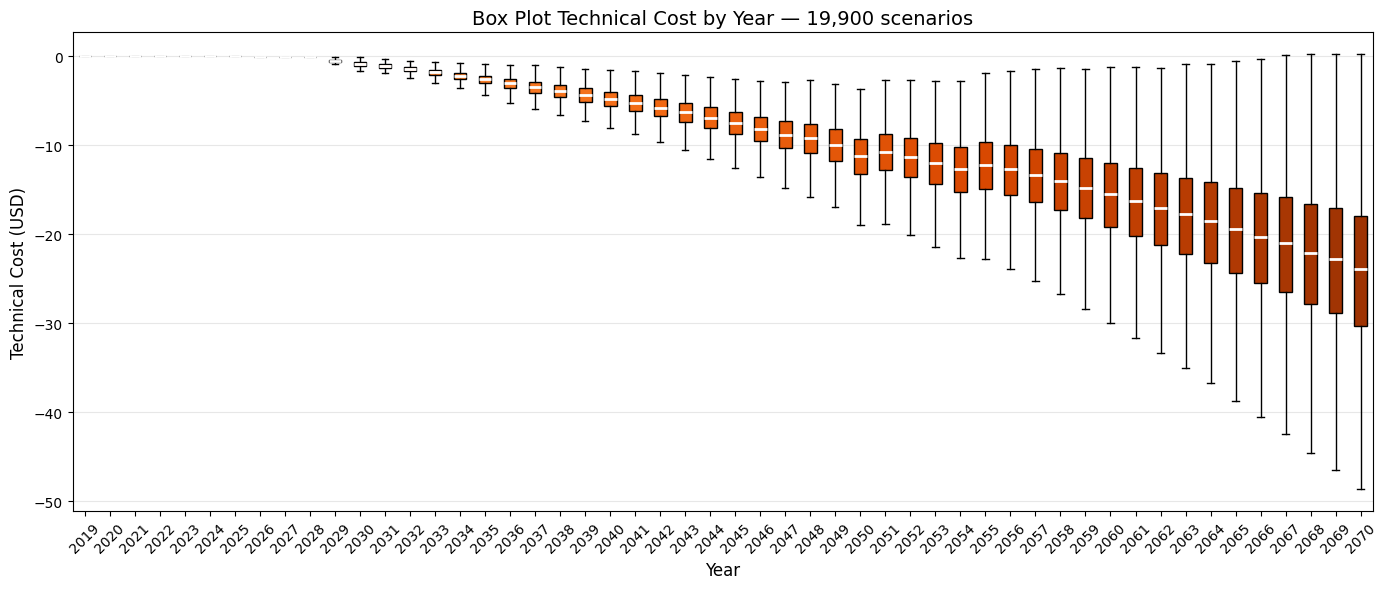

In [115]:
df_cb_plot = df_cb.copy()
df_cb_plot["year"] = df_cb_plot["time_period"] + 2015

cb_grouped    = [group["technical_cost"].values for _, group in df_cb_plot.groupby("year")]
cb_years_list = sorted(df_cb_plot["year"].unique())

fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot(cb_grouped, labels=cb_years_list, patch_artist=True,
                showfliers=False, medianprops=dict(color="white", linewidth=2))

colors = cm.Oranges(np.linspace(0.4, 0.9, len(cb_grouped)))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Technical Cost (USD)", fontsize=12)
ax.set_title(f"Box Plot Technical Cost by Year — {n_cb_ids:,} scenarios", fontsize=14)
ax.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 10c. Spaghetti — one line per primary_id

/var/folders/fj/jc6_dph55kg8wg_040b7gk980000gn/T/ipykernel_51758/2794023664.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10)


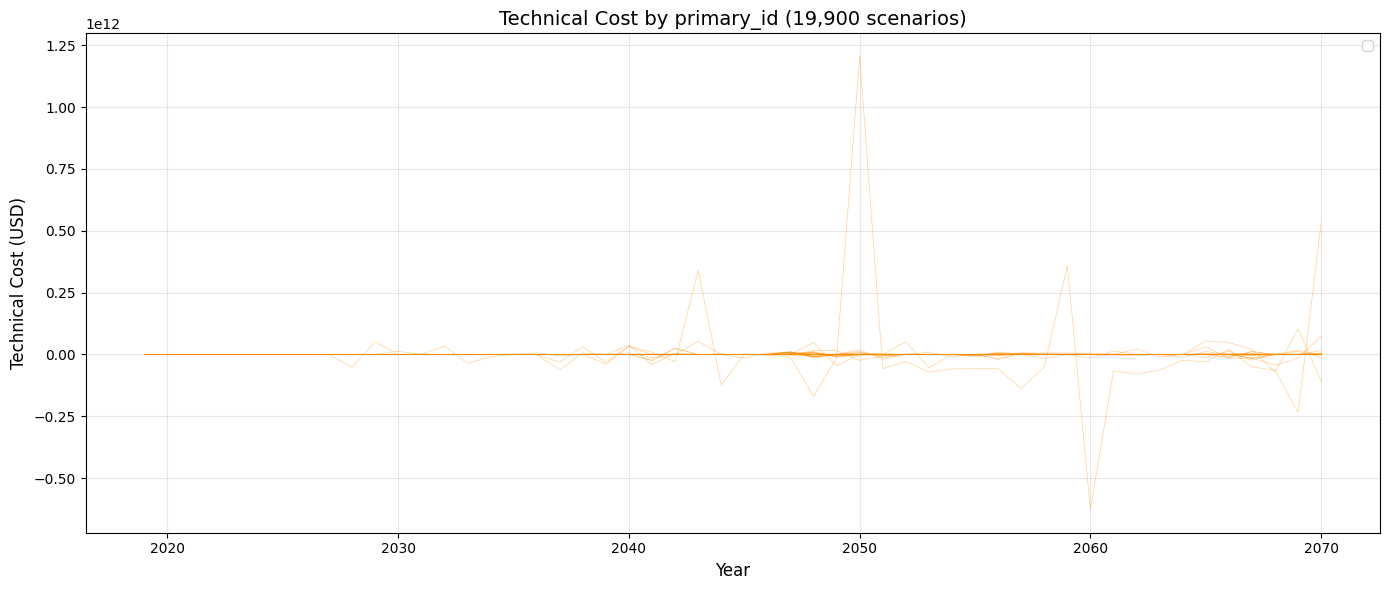

In [116]:
pivot_cb     = df_cb.pivot_table(index="time_period", columns="primary_id", values="technical_cost")
cb_years_arr = pivot_cb.index.values + 2015

fig, ax = plt.subplots(figsize=(14, 6))

# All lines except baseline
non_baseline_cb = [c for c in pivot_cb.columns if c != 0]
ax.plot(cb_years_arr, pivot_cb[non_baseline_cb].values, color="darkorange", linewidth=0.5, alpha=0.4)

# Baseline in red
if 0 in pivot_cb.columns:
    baseline_cb = pivot_cb[0].values
    ax.plot(cb_years_arr, baseline_cb, color="red", linewidth=2, label="Baseline (primary_id=0)", zorder=5)
    ax.annotate(
        "Baseline",
        xy=(cb_years_arr[-1], baseline_cb[-1]),
        xytext=(8, 0),
        textcoords="offset points",
        color="red",
        fontsize=10,
        fontweight="bold",
        va="center",
    )

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Technical Cost (USD)", fontsize=12)
ax.set_title(f"Technical Cost by primary_id ({len(pivot_cb.columns):,} scenarios)", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()